### **A2.2 LDA y árboles de decisióna**

Se continúa usando la base de datos de *Kaggle* llamada **[Titanic Dataset](https://www.kaggle.com/datasets/yasserh/titanic-dataset)**


La limpieza y resolución de problemas con relación a esta base de datos se realizón en el documento [A2.1 Regresión logística y validación cruzada](https://github.com/anagtz0/inteligencia-artificial-I/tree/main/Soluci%C3%B3n%20de%20problemas%20y%20selecci%C3%B3n%20de%20caracter%C3%ADsticas). Debido a esto, se trabajarán con los 4 archivos creados a partir de las varibles `X_test_scaled`, `X_train_scaled`, `y_test`y `y_train`. La variable de salida corresponde a si el pasajero sobrevivió o no. Al hacer la división de conjuntos de *train* y *test* En el documento anterior, se usó la función `stratified`, para mantener la misma proporción de los datos que en la base de datos original (62% no sobrevivientes y 38% sobrevivientes). Esto con el fin de que el modelo no esté sujeto a entrenar con una sola clase y que sólo aprenda a decir que todos no sobrevivieron.


Reiterando, los archivos para la variable `X` después de haber sido manipulados contienen las siguientes variables:


* Pclass: Tipo de clase dentro del barco. 1 = primera clase, 2 = segunda clase, 3 = tercera clase. Sin embargo, fue estandarizada, usando media 0 y desviación estándar 1.
* Sex_male: Sexo del pasajero. 1 = Male y 0 = Female.
* Edad: Valor numérico con la edad del pasajero. Variable estandarizada.
* SibSp: Número de hermanos o parejas del pasajero a bordo. Variable estandarizada
* Parch: Número de padres o hijos del pasajero a bordo.Variable estandarizada.
* Fare: Tarifa pagada por el pasajero. Variable estandarizada.
* Cabin: Número de cabina. También se excluirá del modelo.
* Embarked_Q: Puerto de embarcación. 1 = Queensland.
* Embarked_S: 1 = Southampton.
---






En el bloque de código siguiente se cargan las bases de datos anteriormente mencionadas al espacio de trabajo, importando la librería "pandas" para posteriormente utilizar su función `read_csv()`. Para comprobar que la carga fue exitosa, se utiliza la función `print()` y `head(10)` para imprimir los primeros 10 datos de cada tabla. Para conocer las dimensiones de cada tabla se utiliza la función `.shape`.

















In [59]:
import pandas as pd

X_test_scaled = pd.read_csv('/content/X_test_scaled.csv')
X_train_scaled = pd.read_csv('/content/X_train_scaled.csv')
y_test = pd.read_csv('/content/y_test.csv')
y_train = pd.read_csv('/content/y_train.csv')

print("X_test_scaled (first 10 rows):\n", X_test_scaled.head(10))
print("Shape of X_test_scaled:", X_test_scaled.shape)
print("\nX_train_scaled (first 10 rows):\n", X_train_scaled.head(10))
print("Shape of X_train_scaled:", X_train_scaled.shape)
print("\ny_test (first 10 rows):\n", y_test.head(10))
print("Shape of y_test:", y_test.shape)
print("\ny_train (first 10 rows):\n", y_train.head(10))
print("Shape of y_train:", y_train.shape)

X_test_scaled (first 10 rows):
      Pclass       Age     SibSp     Parch      Fare  Sex_male  Embarked_Q  \
0  0.829568 -0.426860  1.421753 -0.466183 -0.159704      True       False   
1  0.829568  1.109696 -0.465084  0.727782 -0.327324      True       False   
2  0.829568 -0.580516 -0.465084 -0.466183 -0.512122      True       False   
3  0.829568  0.879212  1.421753 -0.466183 -0.368795      True       False   
4  0.829568 -0.081135  0.478335 -0.466183 -0.339817     False        True   
5  0.829568  0.495073  0.478335 -0.466183 -0.300255     False       False   
6 -0.370945  0.495073 -0.465084 -0.466183 -0.391873     False       False   
7 -1.571457  1.186523 -0.465084 -0.466183 -0.109730      True       False   
8 -1.571457  1.493834  0.478335  0.727782  1.646286      True       False   
9 -0.370945  0.341418  0.478335 -0.466183 -0.121182      True       False   

   Embarked_S  
0        True  
1        True  
2       False  
3        True  
4       False  
5        True  
6       





---
#### **Modelo LDA**


Ahora, se construirá un modelo *Least Discriminant Analysis*.


Debido a que este modelo asume normalidad en las variables independientes y las variables binarias no siguen esta distribución, se quitarán de este modelo las variables binarias relacionadas a la embarcación. Sin embargo, debido a que en el modelo de regresión logística realizado previamente mostró que la variable de `Sex` fue la más influyente en el modelo, se decidirá mantener para la construcción de este, para ver cómo afecta mantener esta variable binaria las predicciones. Para esto, se usa la función `.drop()` incluyendo las columnas `Embarked_Q` y `Embarked_S`, tanto para los datos de `X`en `train` y `test`.









In [60]:
X_train = X_train_scaled.drop(columns=['Embarked_Q', 'Embarked_S'])
X_test = X_test_scaled.drop(columns=['Embarked_Q', 'Embarked_S'])

print("X_train (first 10 rows after dropping columns):\n", X_train.head(10))
print("Shape of X_train:", X_train.shape)
print("\nX_test (first 10 rows after dropping columns):\n", X_test.head(10))
print("Shape of X_test:", X_test.shape)

X_train (first 10 rows after dropping columns):
      Pclass       Age     SibSp     Parch      Fare  Sex_male
0  0.829568 -0.081135 -0.465084 -0.466183  0.513812      True
1 -0.370945 -0.081135 -0.465084 -0.466183 -0.662563      True
2 -1.571457 -0.081135 -0.465084 -0.466183  3.955399      True
3  0.829568 -0.887827 -0.465084  0.727782 -0.467874     False
4 -0.370945  0.110934  0.478335  0.727782 -0.115977     False
5  0.829568 -0.657344 -0.465084 -0.466183 -0.486962      True
6  0.829568 -0.273205 -0.465084 -0.466183  0.513812      True
7 -1.571457 -0.081135 -0.465084 -0.466183  4.075040      True
8  0.829568 -0.081135 -0.465084 -0.466183 -0.501190      True
9  0.829568  0.110934  0.478335 -0.466183 -0.287761     False
Shape of X_train: (712, 6)

X_test (first 10 rows after dropping columns):
      Pclass       Age     SibSp     Parch      Fare  Sex_male
0  0.829568 -0.426860  1.421753 -0.466183 -0.159704      True
1  0.829568  1.109696 -0.465084  0.727782 -0.327324      True
2  0.82

Ahora, se continúa con la creación y entrenamiento del modelo LDA. Para comenzar, se importa la librería `LinearDiscriminantAnalysis` que permitirá utilizar las funciones que crearán y entrenarán a este tipo de modelo. Se inicializa el modelo LDA usando la función `LinearDiscriminantAnalysis()`. Estableciendo esto, se asume que los datos tienen una distribución normal y que las clases comparten la misma matriz de covarianza. Con este método se genera una frontera de decisión lineal.
Luego, se usa la función `fit()` que se encarga de ajustar un modelo a los valores de `X_train`, considerando `y_train`. A esta última variable, se le agrega la función `.values.ravel()` debido a que este modelo necesita que la variable categórica se encuentre como un arreglo 1D, no columna tipo dataframe.
Por último, para confirmar que se ejecutó el código, se imprime un mensaje informando que el modelo LDA se entrenó exitosamente.  
Luego, para evaluar al modelo con los datos de *train* se generan las predicciones para `y` usando el modelo creado y las variables `X_train`. Estos resultados se guardan en una variable llamada `y_pred_lda_train`. Después, se importan las librerías `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `classification_report`(para las métricas). Se obtienen estos valores usando los parámetros de `y_train` y `y_pred_lda_train` y después se imprimen estos resultados.









In [61]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Initialize the LDA model
lda = LinearDiscriminantAnalysis()

# Train the LDA model
lda.fit(X_train, y_train.values.ravel())

print("LDA model trained successfully.")

LDA model trained successfully.


In [62]:
y_pred_lda_train = lda.predict(X_train)
print("LDA predictions generated successfully for training data.")

LDA predictions generated successfully for training data.


In [63]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_train = accuracy_score(y_train, y_pred_lda_train)
precision_train = precision_score(y_train, y_pred_lda_train)
recall_train = recall_score(y_train, y_pred_lda_train)
f1_train = f1_score(y_train, y_pred_lda_train)

print(f"Accuracy on training data: {accuracy_train:.4f}")
print(f"Precision on training data: {precision_train:.4f}")
print(f"Recall on training data: {recall_train:.4f}")
print(f"F1-score on training data: {f1_train:.4f}")

Accuracy on training data: 0.7949
Precision on training data: 0.7530
Recall on training data: 0.6923
F1-score on training data: 0.7214


Los resultados obtenidos para las métricas son los siguientes:
* Accuracy (proporción total de predicciones correctas): 0.7949 -> Esto quiere decir que el modelo clasifica correctamente el 79.5% de los pasajeros en los datos de entrenamiento.
* Precision (Verdaderos sobrevivientes de todos los que fueron marcados como sobrevivientes): 0.753 -> Esto significa que si el modelo indica que una persona sobrevivió, tiene una probabilidad de 75.3% de estar en lo correcto.
* Recall (Proporción de los verdaderos positivos): 0.6923 -> De todos los pasajeros que realmente sobrevivieron, el modelo identificó correctamente 69.2%.
* F1-score (Promedio armónico entre precision y recall): 0.7214 -> Indica ser un modelo con desempeño moderadamente bueno y balanceado. En buen balance entre precisión y sensibilidad.




Se imprimirán los valores de los coeficientes (weights) de cada variable, además se va imprimirá toda la función de discriminación de la clase `Survived`. Para iniciar, se guardan los nombres de las columnas de las variables independientes en `features_names`. Luego, se imprimen los coeficientes usando un `for` loop y usando la función `lda.coef` para cada variable. Después se imprime el intercepto de esta función con `lda.intercept`.


Luego, para imprimir la función, se comienza por imprimir el intercepto del modelo, con la misma función que se usó anteriormente, usando el parámetro `end=""` para poder seguir imprimiendo los demás coeficientes en la misma línea. Después, se inicializa un `for` loop para que vaya recorriendo todas las variables e imprimiendo cada uno de los coeficientes usando la función `lda.coef_`. Por último, se imprime una leyenda que indica la línea que separa las clases; si el modelo es mayor a 0, la predicción suele ser `Survived` (1), de cualquier otro modo, el modelo tiende a predecir `Not Survived` (0).









In [64]:
feature_names = X_train.columns

# Print coefficients
print("Coefficients (weights) for each feature:")
for i, feature in enumerate(feature_names):
    print(f"  {feature}: {lda.coef_[0][i]:.4f}")

# Print intercept
print(f"\nIntercept: {lda.intercept_[0]:.4f}")

print("\nInterpretation: The discrimination function for Class 1 (Survived) is approximately:")
print(f"f(x) = {lda.intercept_[0]:.4f} + ", end="")
for i, feature in enumerate(feature_names):
    if i > 0: # Add '+' for subsequent terms
        print(f" + ", end="")
    print(f"({lda.coef_[0][i]:.4f} * {feature})", end="")
print("\n\nIf f(x) > 0, the model tends to predict 'Survived' (class 1); otherwise, it predicts 'Did Not Survive' (class 0).")

Coefficients (weights) for each feature:
  Pclass: -1.0060
  Age: -0.5377
  SibSp: -0.2614
  Parch: -0.1218
  Fare: 0.1369
  Sex_male: -3.5944

Intercept: 1.5141

Interpretation: The discrimination function for Class 1 (Survived) is approximately:
f(x) = 1.5141 + (-1.0060 * Pclass) + (-0.5377 * Age) + (-0.2614 * SibSp) + (-0.1218 * Parch) + (0.1369 * Fare) + (-3.5944 * Sex_male)

If f(x) > 0, the model tends to predict 'Survived' (class 1); otherwise, it predicts 'Did Not Survive' (class 0).


Se obtuvieron los siguientes coeficientes, acompañados de una breve interpretación:
* Pclass: -1.0060 -> Entre mayor la clase, menor probabilidad de sobrevivir.
* Age: -0.5377 -> A mayor edad, menor probabilidad de sobrevivir.
* SibSp: -0.2614 -> A mayor número de hermanos o cónyuges a bordo, menor probabilidad de sobrevivir.
* Parch: -0.1218 -> A mayor número de padres o hijos a bordo del barco, menor la probabilidad de supervivencia.
* Fare: 0.1369 -> A mayor el precio, mayores probabilidades de sobrevivir. Esto se puede deber a que a las clases más altas se les suele dar prioridad en catástrofes.
* Sex_male: -3.5944 -> Este valor indica que el pasajero es hombre, la probabilidad de sobrevivir decrementa significativamente. Esto tiene sentido, debido a la política de "women and children first".


A pesar de que la variable `Sex_male` es una variable que no sigue una distribución normal, al ser binaria, los resultados obtenidos con este método resultan bastante razonables. Además, el sentido de los coeficientes son iguales que los obtenidos con un modelo de regresión logística, usando en el reporte enlazado al inicio de éste.  





---


Ahora, se creará una gráfica para visualizar el umbral de corte del modelo para tomar decisiones. Para esto, se importan las librerías `matplotlib.plyplot`, para poder generar la gráfica, y `seaborn`, para la visualización de los datos.


Se inicia por crear un DataFrame con los elementos a graficar, usando la función `flatten()` para convertir los datos en un arreglo 1D y que no cause ningún inconveniente.


Posteriormente se crea la figura con `plt.figure()` y se usa la función `histplot()`, dándole como parámetros `x='LDA Component 1'`, que son los valores proyectados en la función discriminante, y `hue='Survived'`, que separa las distribuciones por clase para que cada una tenga su propio color. Además, se le agrega `kde=True`que genera una curva suavizada para mejor visualización. Por último, se agrega la frontera de decisión con `plt.axvline` dando un valor de x = 0, debido a que al ser una clasificación binaria y la función anterior arrojó este valor. Finalmente se grafica lo anterior muestra lo anterior con `plt.show()`, antes añadiendo títulos a los ejes y a la gráfica, , al igual que leyendas a los colores y líneas en el gráfico.  





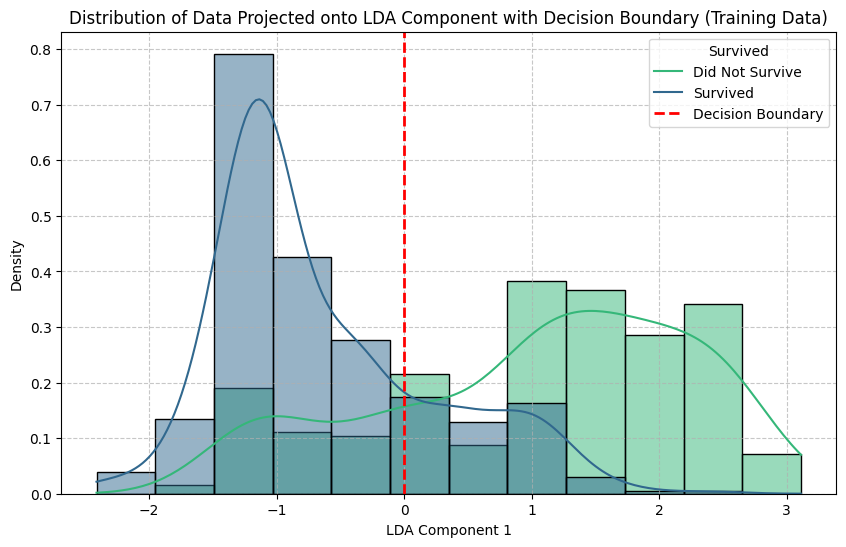

Visual representation of the LDA discriminant function with decision boundary generated for training data.


In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# Project the training data onto the single LDA component
X_train_lda = lda.transform(X_train)

# Create a DataFrame for plotting
lda_df_train = pd.DataFrame({
    'LDA Component 1': X_train_lda.flatten(),
    'Survived': y_train['Survived']
})

# Plot the distributions
plt.figure(figsize=(10, 6))
sns.histplot(data=lda_df_train, x='LDA Component 1', hue='Survived', kde=True, palette='viridis', stat='density', common_norm=False)

# Add a vertical line at LDA Component 1 = 0, which is the decision boundary
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Decision Boundary (LDA Component 1 = 0)')

plt.title('Distribution of Data Projected onto LDA Component with Decision Boundary (Training Data)')
plt.xlabel('LDA Component 1')
plt.ylabel('Density')
plt.legend(title='Survived', labels=['Did Not Survive', 'Survived', 'Decision Boundary'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("Visual representation of the LDA discriminant function with decision boundary generated for training data.")

En la gráfica, la densidad mostrada en el eje `y` equivale a la distribución de cada clase. **LDA Component 1** representa la proyección de los datos sobre la función discriminante. Se puede observar una clara separación de los datos, aunque no perfecta, ya que los valores azules (Survived) predominan en un lado de la línea roja, mientras que los verdes (Not Survived) predominan el otro lado. Sin embargo, sí hay un solapamiento de los datos en el área de decisión que no permite que el modelo pueda predecir de mejor manera.





---


Ahora, se va a probar la calidad de este modelo usando los datos de *test*. Se crean las predicciones de `y`, usando la función `lda.predict`, usando los datos de `X_test`. Después se imprime indicando que se crearon exitosamente. Después, se calculan todas las métricas usadas para evaluar el desempeño del modelo empleadas anteriormente en el reporte (accuracy, precision, recall, f1 score). Estas métricas se calculan ingresando los datos reales de `y_test` y las predicciones hechas para esta misma variable.











In [66]:
y_pred_lda = lda.predict(X_test)
print("LDA predictions generated successfully.")

LDA predictions generated successfully.


In [67]:
accuracy = accuracy_score(y_test, y_pred_lda)
precision = precision_score(y_test, y_pred_lda)
recall = recall_score(y_test, y_pred_lda)
f1 = f1_score(y_test, y_pred_lda)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.8045
Precision: 0.7833
Recall: 0.6812
F1-score: 0.7287


Para la prueba, el modelo presentó lo siguiente:


* Accuracy (proporción total de predicciones correctas): 0.8045 -> Esto quiere decir que el modelo clasifica correctamente el 80.5% de los pasajeros en los datos de entrenamiento. Ligeramente mejor que con los datos de prueba.
* Precision (Verdaderos sobrevivientes de todos los que fueron marcados como sobrevivientes): 0.7833 -> Esto significa que si el modelo indica que una persona sobrevivió, tiene una probabilidad de 78.3% de estar en lo correcto.
* Recall (Proporción de los verdaderos positivos): 0.6812 -> De todos los pasajeros que realmente sobrevivieron, el modelo identificó correctamente 68.1%.
* F1-score (Promedio armónico entre precision y recall): 0.7287 -> Indica ser un modelo con desempeño moderadamente bueno y balanceado. En buen balance entre precisión y sensibilidad.


En general, el modelo muestra tener moderadamente buena habilidad predictiva y de generalización, además de que no parece estar sobre ajustado. Sin embargo, el modelo pierde alrededor del 32% de los sobrevivientes reales.


---
#### **Modelo basado en árboles de decisión**


Ahora, se creará un modelo basado en árboles de decisión, abordando el mismo problema.





---

#### **Modelo basado en árboles de decisión**

Ahora, se creará un modelo basado en árboles de decisión, abordando el mismo problema.

Para inciar, se importa la librería `DecisionTreeClassifier`, para poder usar todas las funciones necesarias para crear un modelo de este tipo. Luego, se inicializa el modelo con la función `DecisionTreeClassifier`, agregando la semilla de aleatoriedad `random_state=42` para que el resultado sea reproducible que que se obtenga el mismo árbol siempre. Posteriormente, se entrena el modelo dándole como parámetros `X_train` y `y_train`.

In [68]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree model
dtc = DecisionTreeClassifier(random_state=42)

# Train the Decision Tree model
dtc.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


Ahora, se calculan las métricas para ver el desempeño del modelo en los datos de entrenamiento. Se usan las mismas funciones y variables de entrada (correspondiente a este modelo) que en los cálculos de estas métricas realizados anteriormente.
Después, se crea e imprime una visualización del árbol de decisión creado. Se importa la librería `plot_tree`, donde se le ingresan como parámetros el modelo creado `dtc`, además de los nombres de las variables convertidas a *string*, además de los nombres de las clases y agregando un límite de profundidad de 3, para poder mantener la legibilidad.  









Accuracy on training data: 0.9831
Precision on training data: 0.9962
Recall on training data: 0.9597
F1-score on training data: 0.9776


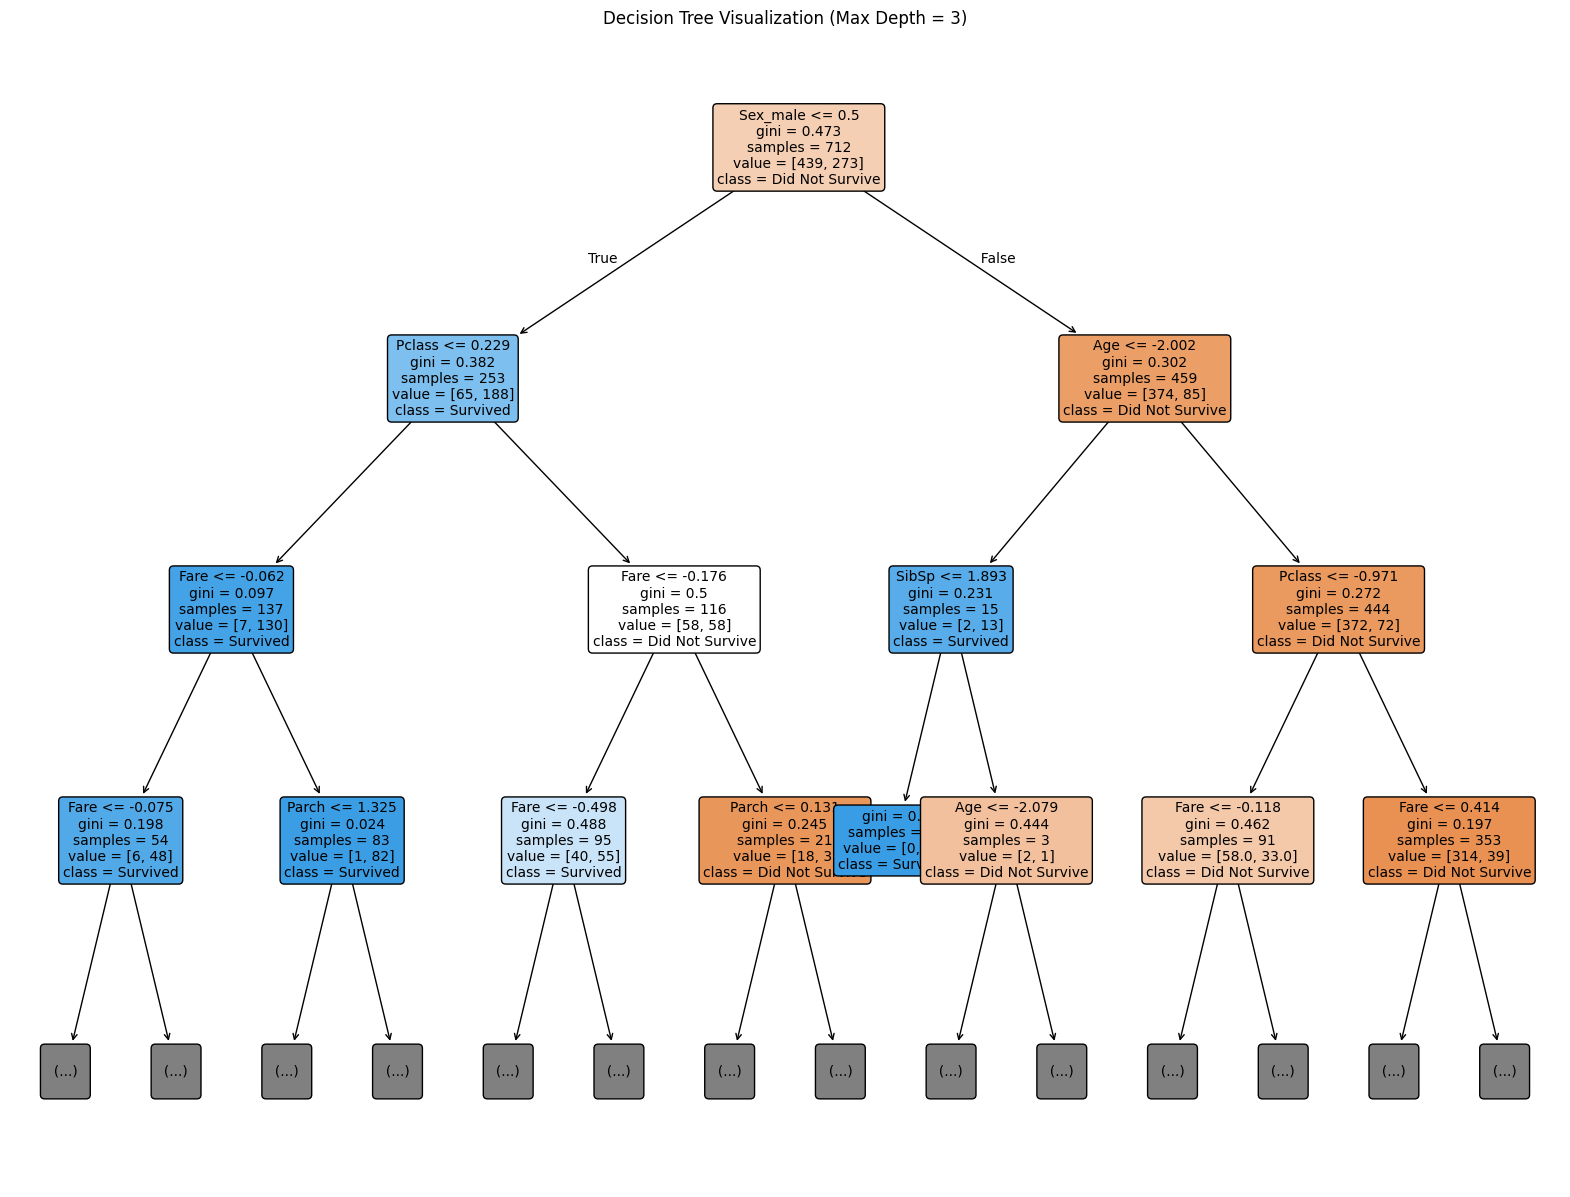

In [69]:
# Make predictions on the training data
y_pred_dtc_train = dtc.predict(X_train)

# Calculate metrics for training data
accuracy_dtc_train = accuracy_score(y_train, y_pred_dtc_train)
precision_dtc_train = precision_score(y_train, y_pred_dtc_train)
recall_dtc_train = recall_score(y_train, y_pred_dtc_train)
f1_dtc_train = f1_score(y_train, y_pred_dtc_train)

print(f"Accuracy on training data: {accuracy_dtc_train:.4f}")
print(f"Precision on training data: {precision_dtc_train:.4f}")
print(f"Recall on training data: {recall_dtc_train:.4f}")
print(f"F1-score on training data: {f1_dtc_train:.4f}")


# Tree visualization
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 15))
plot_tree(dtc,
          feature_names=X_train.columns.tolist(),  # Ensure feature names are strings
          class_names=['Did Not Survive', 'Survived'],
          filled=True,
          rounded=True,
          max_depth=3,  # Limit depth for readability
          fontsize=10)
plt.title('Decision Tree Visualization (Max Depth = 3)')
plt.show()

Como se observa, el modelo parecería ser un gran modelo, debido a que se obtuvieron valores para las 4 métricas mayores al 90%. Sin embargo, esto podría deberse a sobreajuste del modelo, posibilidad que aumenta cuando se analiza el gráfico visual del árbol de decisión, donde se puede observar que hay múltiples ramas para cada rama. Es por eso que ahora se pondrá a prueba el modelo con los datos de *test*.


  Se hacen las predicciones con `predcit(X_test)`para el modelo dtc. Después se calculan las métricas usando las mismas funciones ya mencionadas y dándoles como parámetros `y_test` y `t_pred_dtc_test`.





In [70]:
# Make predictions on the test data
y_pred_dtc_test = dtc.predict(X_test)

# Calculate metrics for test data
accuracy_dtc_test = accuracy_score(y_test, y_pred_dtc_test)
precision_dtc_test = precision_score(y_test, y_pred_dtc_test)
recall_dtc_test = recall_score(y_test, y_pred_dtc_test)
f1_dtc_test = f1_score(y_test, y_pred_dtc_test)

print(f"Accuracy on test data: {accuracy_dtc_test:.4f}")
print(f"Precision on test data: {precision_dtc_test:.4f}")
print(f"Recall on test data: {recall_dtc_test:.4f}")
print(f"F1-score on test data: {f1_dtc_test:.4f}")



Accuracy on test data: 0.8045
Precision on test data: 0.7656
Recall on test data: 0.7101
F1-score on test data: 0.7368


Como se puede obsercar, el modelo ahora es menos precisio para predecir las clases, aunque sigue siendo un mejor número que el obtenido con el modelo LDA. Sin embargo, todas las demás métricas bajaron; de los pasajeros que predice como sobrevivientes, sólo el 76.56% de las veces está correcto. Sólo identificó el 71.01% de las personas que sí sobrevivieron. Y tuvo un F1-score de 0.7368.
Aunque incluso con estos valores se podría considerar un modelo considerablemente bueno (al obtuvo mejores métricas que el modelo LDA anteriormente calculado), esta variación significativa entre las métricas con los datos de *train* y *test* podría indicar sobreajuste en el modelo, debido a todas las ramas que actualmente contiene. Es por eso que es hora de podar el modelo para posteriormente evaluarlo y comparar.

Para iniciar, se usará el *cost-complexity pruning* para poder el árbol, además de una búsqueda en cuadrícula con validación cruzada para encontrar el valor óptimo de α. Se inicia reinciando el modelo y guadándolo en la variable `pruning_dtc`. Luego, se calcula el camino de poda, donde se entrea un árbol completo, luego se calculan todas las posibilidades de podas sucesivas para después genera una seciencia de valores de `ccp_alpha`.Se va haciendo un camino de un árbol grande hasta llegar a uno pequeño. Luego, se obtiene los valores de `ccp_alphas` y las `impurities`, que son las impuerazas del árbol en cada nivel de poda. Luego, se elimina el último alpha con `ccp_alpha[:-1]`, debido a que este es un árbol con sólo la raíz, no hay divisiones. Por último, se imprimen todos los valores generados para α, además de la longuitud de esta lista.






In [71]:

# Re-initialize the Decision Tree model or use the existing dtc if available
# For generating the pruning path, it's often good practice to use a fresh instance or the one you plan to prune.
# Here, we'll re-initialize for clarity for this specific step.
pruning_dtc = DecisionTreeClassifier(random_state=42)

# Calculate the cost complexity pruning path
path = pruning_dtc.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Remove the maximum ccp_alpha value (corresponds to the root-only tree)
ccp_alphas = ccp_alphas[:-1]

print("Generated ccp_alphas for pruning:")
print(ccp_alphas)
print(f"Number of ccp_alphas: {len(ccp_alphas)}")

Generated ccp_alphas for pruning:
[0.00000000e+00 5.01605136e-05 1.17041199e-04 1.17041199e-04
 1.40449438e-04 2.34082397e-04 2.80898876e-04 3.40483487e-04
 4.68164794e-04 5.99766142e-04 6.24219725e-04 6.55430712e-04
 7.02247191e-04 7.34167518e-04 7.83459451e-04 8.42696629e-04
 8.42696629e-04 8.51208716e-04 8.56248768e-04 9.13492281e-04
 9.25048509e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 1.05337079e-03 1.09238452e-03 1.12359551e-03 1.12359551e-03
 1.12359551e-03 1.13399917e-03 1.17041199e-03 1.20385233e-03
 1.22008991e-03 1.26404494e-03 1.26404494e-03 1.27965044e-03
 1.30726016e-03 1.32934755e-03 1.33761370e-03 1.39043527e-03
 1.41927853e-03 1.42530171e-03 1.44811030e-03 1.54786985e-03
 1.63087670e-03 1.66464505e-03 1.80577849e-03 1.83715006e-03
 1.87265918e-03 1.91418992e-03 2.13481281e-03 2.22935616e-03
 2.24719101e-03 2.24719101e-03 2.29826353e-03 2.40770465e-03
 2.46750701e-03 2.64847512e-03 2.99625468e-03 3.00037042e-03
 3.14422300e-03 3.26935081e-03 3.40088283e-03 3.859

Se obtuvieron 72 alphas por probar.


Ahora, se buscará el mejor valor de `ccp_alpha` usando la validación cruzada de 5 *folds*. Se usará `GridSearchCV` debido a que sirve para automatizar la búsqueda de los mejores hiperparámetros. A esta función se le ponen como parámetros el modelo creado, los valores de alpha encontrados anteriormente, `cv=5`, que indica la validación cruzada de 5 *folds* (entrena con 4, valida con 1) y el criterio para elegir el mejor α (`scoring='accuracy'`). Con `grid_search.fit()` con los datos de entrenamiento para `X` y `y` lo que ocurre es que para cada valor de α, se entrenan 5 árboles, donde se calcula el `accuracy` promedio y se guarda el resultado. Por último, se busca busca el mejor valor de α usando la función `.best_params_`. En ningún momento se trabaja con los datos de prueba para encontrar este valor para que no haya fuga de datos.







In [72]:
from sklearn.model_selection import GridSearchCV


# Define the parameter grid for ccp_alpha
param_grid = {
    'ccp_alpha': ccp_alphas
}

# Initialize the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=dt_classifier,
                           param_grid=param_grid,
                           cv=5,  # 5-fold cross-validation
                           scoring='accuracy', # Use accuracy as the scoring metric
                           verbose=1,
                           n_jobs=-1) # Use all available cores

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best ccp_alpha
best_ccp_alpha = grid_search.best_params_['ccp_alpha']

print(f"Optimal ccp_alpha found: {best_ccp_alpha:.6f}")


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Optimal ccp_alpha found: 0.004242


Ahora que ya se encontró el valor de α = 0.004242, se va a crear un nuevo árbol de decisión con este valor. Se siguen los mismos pasos que en el modelo creado anteriormente, sin valor de alpha, sólamente que esta vez se añadirá el parámetro de `ccp_alpha=best_cpp_alpha` para que el modelo use este valor. Para el `fit()` se usan los datos de `X_train` y `y_train`.  
  Ya que está creado el modelo, se evalúa el desempeño del modelo para los valores de prueba, usando las mismas funciones y métricas usadas anteriormente.
  Por último, se calcula e imprime la profundidad de cada modelo para poder hacer una comparación de estos valores en el análisis, con la función `max_depth`.









In [76]:
dtc_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=best_ccp_alpha)
dtc_pruned.fit(X_train, y_train)

print(f"Pruned Decision Tree model trained successfully with ccp_alpha = {best_ccp_alpha:.6f}.")

# Make predictions on the test data with the pruned model
y_pred_dtc_pruned_test = dtc_pruned.predict(X_test)

# Calculate metrics for the pruned model on test data
accuracy_dtc_pruned_test = accuracy_score(y_test, y_pred_dtc_pruned_test)
precision_dtc_pruned_test = precision_score(y_test, y_pred_dtc_pruned_test)
recall_dtc_pruned_test = recall_score(y_test, y_pred_dtc_pruned_test)
f1_dtc_pruned_test = f1_score(y_test, y_pred_dtc_pruned_test)

print(f"Pruned Decision Tree Accuracy on test data: {accuracy_dtc_pruned_test:.4f}")
print(f"Pruned Decision Tree Precision on test data: {precision_dtc_pruned_test:.4f}")
print(f"Pruned Decision Tree Recall on test data: {recall_dtc_pruned_test:.4f}")
print(f"Pruned Decision Tree F1-score on test data: {f1_dtc_pruned_test:.4f}")


print(f"Depth of the original Decision Tree model: {dtc.tree_.max_depth}")
print(f"Depth of the pruned Decision Tree model: {dtc_pruned.tree_.max_depth}")


Pruned Decision Tree model trained successfully with ccp_alpha = 0.004242.
Pruned Decision Tree Accuracy on test data: 0.7430
Pruned Decision Tree Precision on test data: 0.7170
Pruned Decision Tree Recall on test data: 0.5507
Pruned Decision Tree F1-score on test data: 0.6230
Depth of the original Decision Tree model: 23
Depth of the pruned Decision Tree model: 5


Con este modelo con el árbol podado, las métricas obtenidas demuestran que el modelo se volvió peor para predecir. Ahora, sólo está correcto el 74.3% de las predicciones que hace. Además, de las personas que realmente sobrevivieron, sólo predice correctamente el 55.07% de ellas, marcando a casi la mitad como muertas.

###Comparación de modelo de árbol original vs. podado

**Modelo original en datos de test**
* Accuracy: 0.8045
* Precision: 0.7656
* Recall: 0.7101
* F1-score: 0.7368

**Modelo podado en datos de test**
* Accuracy: 0.7430
* Precision: 0.7170
* Recall: 0.5507
* F1-score: 0.6230

Un modelo podado suele tener menos ramas y menos profundidad que el modelo original. En este caso, el modelo original tiene 23 capas de profundidad, mientras que el modelo podado sólo tiene 5.

Se puede observar que claramente el modelo original alcanzó métricas más altas en los datos de prueba, comparado con el modelo podado.  El haber obtenido estas métricas indica que el valor óptimo encontrado para α pudo haber podado el árbol de más, causando *underfitting*.




A continuación, se mostrará visualmente el árbol podado, para posteriormente hacer un análisis. Se usan las mismas funciones utilizadas para crear el árbol anterior. Para esto, debido a que es más pequeño y puede ser legible con todos sus niveles de profundidad, se dejarán los 5 niveles que conforman a este modelo.









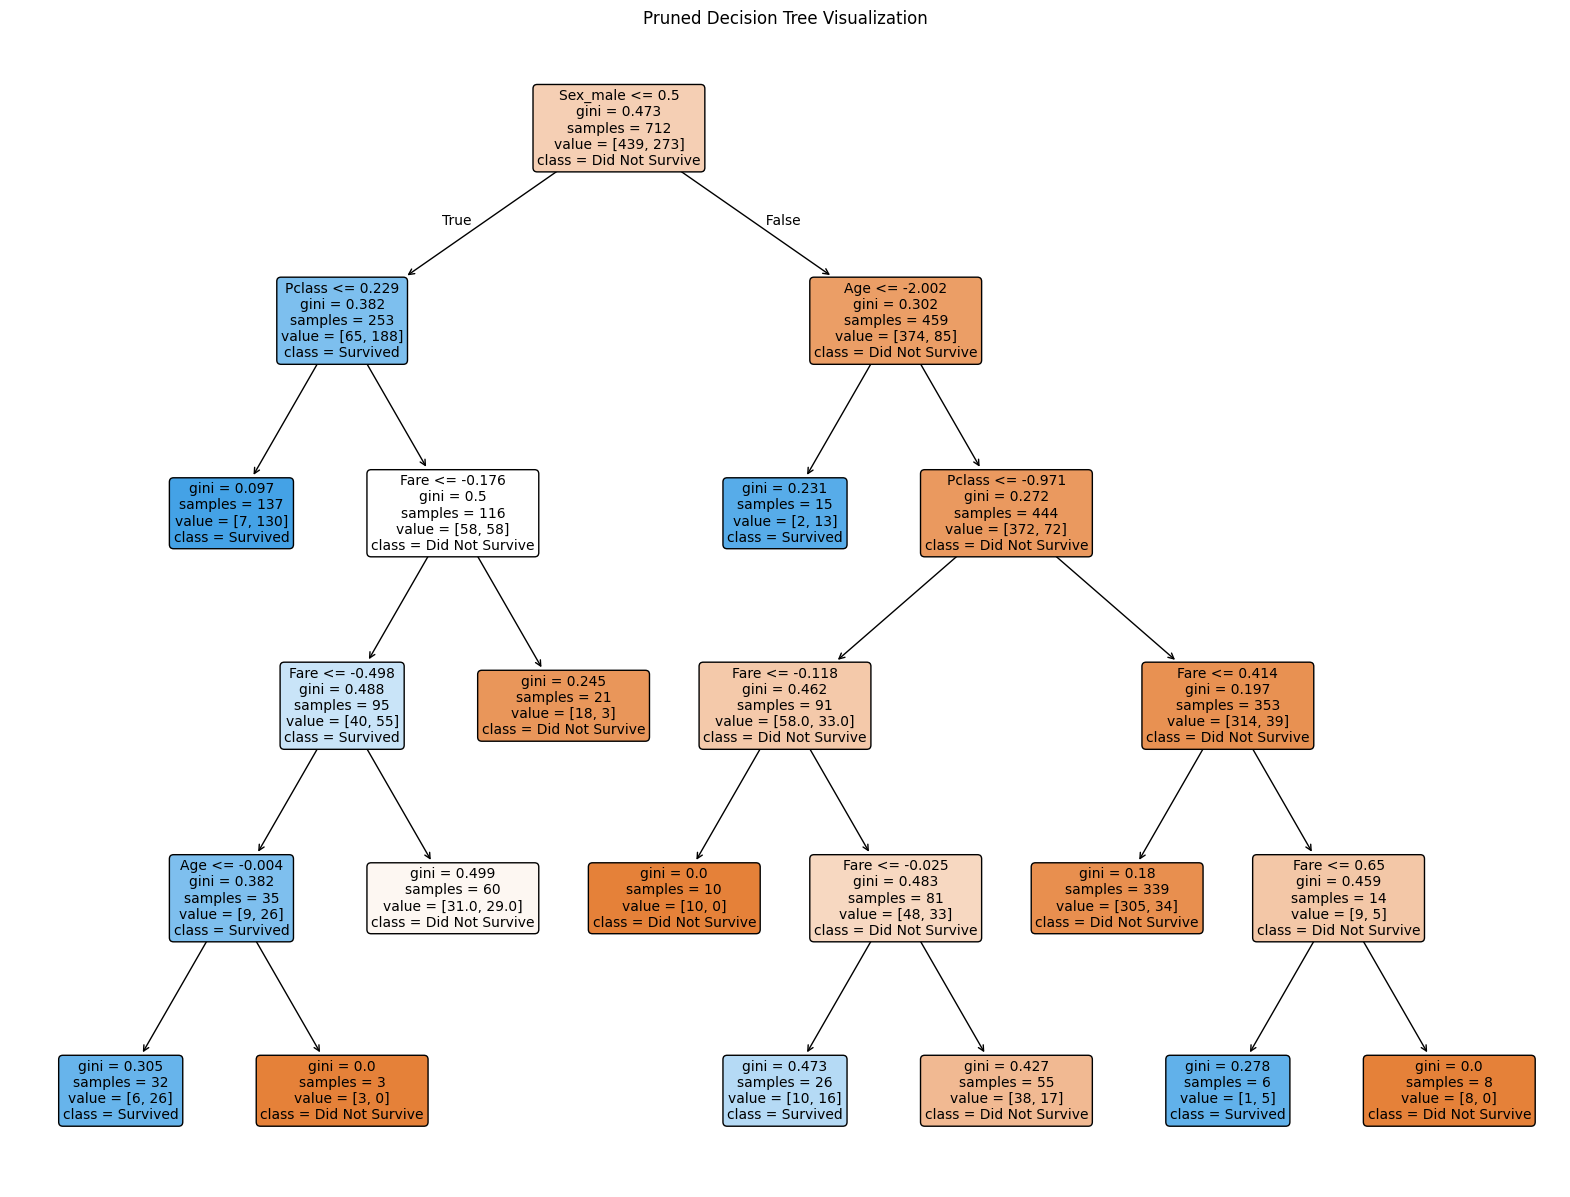

In [78]:
plt.figure(figsize=(20, 15))
plot_tree(dtc_pruned,
          feature_names=X_train.columns.tolist(),
          class_names=['Did Not Survive', 'Survived'],
          filled=True,
          rounded=True,
          max_depth=5,
          fontsize=10)
plt.title('Pruned Decision Tree Visualization')
plt.show()

Debido a que las variables habían sido estandarizadas previamente, se obtienen valores poco interpretables para el modelo. Para mejor entendimiento, se debería convertir en valores reales.


1. Nodo 1:
`Sex_male<=0.5` -> Pregunta si es hombre (1) o mujer (0). La impureza de este nodo es de 0.473 (`gini`). Este se busca que sea lo más cercano a 0. El `Not Survived` indica que la mayoría de las personas no sobrevivieron, en esa muestra.
El género es un factor determinante para la supervivencia ante una catástrofe marítima de este estilo, según este modelo.




2. Nodo 2
* Lado Izquierdo -> Mujer.
  Pregunta el tipo de clase `Pclass <= 0.229`(esta variable fue previamente estandarizada). La clase mayoritaria dentro de este grupo sí sobrevivió. Si la respuesta a la pregunta anterior es **Sí** (si es una clase baja en número, no en categoría), entonces la persona sobrevivió. En ese grupo 7 personas no sobrevivieron pero 130 sí. Lo cual puede dar tranquilidad en la confiabilidad de la predicción. Por el contrario, si la respuesta fue **No**, entonces se pregunta cuál fue el precio pagado por el boleto `Fare <=-0.176`. Si el precio fue mayor a eso, entonces se predice que la persona no sobrevivió (con 18 personas no sobrevivientes y 3 sí en ese grupo). Por el contrario, si el precio fue menor o igual a eso, entonces se le vuelve a preguntar por el precio pagado, ahora con otro valor `Fare <= -0.498`. Si el precio no es menor a eso, se predice que ese pasajero no sobrevivió (con 31 personas no sobrevivientes y 29 que sí, lo cuál no indica mucha seguridad en la predicción). Aunque, si el precio sí es menor o igual a -0-498, entonces se le pregunta la edad al pasajero `Age <= -0.004`. Si la edad sí es mejor o igual a -0.004, entonces la personas se le indica que sobrevive. De lo contrario, se predice que no sobrevive (aunque ese grupo sólo tiene 3 muestras y todas son de la categoría `Not Survived`.




* Lado derecho -> Hombre
  Pregunta la edad de la persona `Age <= -2.002`. Si la respuesta es que la edad sí es menor o igual a ese número, entonces se predice que la persona sí sobrevivió. De lo contrario, se le pregunta la clase de la cabina comprada `Pclass <= -0-971`.
    * Si es menor, se le pregunta el precio pagado por el boleto `Fare <= -0-118`. Si sí es menor o igual a este valor, se predice que la persona no sobrevive. Si no es menor, se le vuelve a preguntar el precio pagado por el boleto `Fare <= -0-025`. Si sí es menor o igual a esa cantidad, entonces se predice que la persona sobrevivió (10 personas no sobrevivieron y 16 sí, en ese grupo). De lo contrario se predice que el pasajero no sobrevivió.
    * Si la `Pclass` es mayor que el valor establecido, se le pregunta el precio pagado `Fare <= 0.414`. Si el precio es menor o igual a eso, entonces se predice que la persona no sobrevivió. Por el contrario, se le vuelve a preguntar el precio del boleto `Fare <= 0.65`. Si es menor o igual, se predice que la persona sobrevivió (con 5 personas sobrevivientes y 1 no en este grupo). Si el valor del precio es mayor al de la condición, entonces se predice que el pasajero no sobrevive (8 de las personas no sobrevivieron, 0 sí sobrevivieron).




  Este árbol podado no incluye las variables de `SibSp` ni `Parch`.




  De este árbol, se puede ver que las mujeres de la clase alta (primera clase) tienen más probabilidades de sobrevivir. En cambio, con los hombres, lo primero que se les pregunta es la edad, debido a se les daba prioridad a los niños, debido a que los hombres adultos/jóvenes no eran prioridad de ser salvados. Para ambos géneros, el precio pagado por el precio podría determinar si la persona sobrevivía o no. Esto recalca la idea de que las personas privilegiadas son las que se les da prioridad en una catástrofe.




  ---
  #### **Comparación de modelo LDA y basado en árboles de decisión***






##### **Métricas vs. Visualizaciones**
Para el modelo LDA, en la gráfica creada para poder visualizar el comportamiento de las variables y la frontera de decisión parece mostrar una separación clara, aunque con algo de solapamiento. La frontera establecida para determinar las clases en 0 parece adecuada, debido a que ahí es donde parecería que no dominan ninguna de las 2 clases. Con un *accuracy* del 80.4% y un recall de 68%, parecería indicar que el modelo tiene un desempeño moderado. El modelo no alcanza mejores valores de métricas por el solapamiento que hay en los datos de `Survived` y `Not Survived` que se puede apreciar en la representación visual.


Por otro lado, se tiene el modelo basado en árboles de decisión. En la representación visual se pueden apreciar claramente que las reglas se basan en las variables `Sex`, `Pclass` y `Age`. Este es un árbol simplificado son 5 niveles de profundidad. Esta estructura visual permite un fácil entendimiento de qué sucede, incluso para el público en general. Lo único que tiene de desventaja en interpretabilidad es que el modelo se realizó con variable estandarizadas, debido a que así venía el archivo de los datos. Para una mejor interpretabilidad de este árbol, sería recomendable revertir este proceso. Otra desventaja que tiene este modelo es que, aunque las reglas son claras y fáciles de entender, las métricas son muy bajas, con una capacidad de identificar a sólo el 55% de los sobrevivientes (recall) y un 74.3% de exactitud. Se sacrifica capacidad de predicción por tener mejor interpretabilidad, a diferencia del modelo hecho con LDA.


##### **Influencia de los supuestos del modelo**


El modelo LDA asume normalidad de las variables, además de homocedasticidad (que indica igualdad en las matrices de covarianza) y que las fronteras limitantes entre cada clase son lineales. Incluso teniendo el caso del género, que es una variable binaria, el modelo parece tener una moderada/buena capacidad predictiva, incluso los coeficientes y sus sentidos tienen coherencia con el contexto del problema. Por lo que para este caso, estos supuestos no parecen haber afectado significativamente el modelo y sus métricas.


Para el modelo basado en árboles de decisión, no se requiere que los datos se comporten de manera normal, además de que suele ser más flexible. Sin embargo, es mejor que las zonas de decisión tengan el mayor nivel de pureza para tener una mejor capacidad de predecir, además de que este tipo de modelos son más propensos a sobreajustes si no se frenan a tiempo, como se pudo observar en este reporte. Para este caso, no se obtuvo el mejor modelo, por lo que no parece conveniente sacrificar las buenas métricas y capacidad de predicción por mayor interpretabilidad.


##### **Ventajas y limitaciones**


Para el modelo LDA, las ventajas son que tuvo un mejor desempeño a la hora de probar los datos de *test*, además de parece un modelo más estable, al no tener tanta variación en los valores de las métricas en ambos conjuntos de datos (*train* y *test*). Sin embargo, no es tan interpretable con el modelo basado en árboles de decisión, debido a que no tiene reglas concretas como tal.


Por el contrario, el modelo basado en árboles de decisión sí es mucho más interpretable, teniendo las reglas ahí expuesta, se puede seguir el camino que vaya cumpliendo con los criterios del pasajero para llegar a la predicción. No obstante, como ya se mencionó, el modelo tiene un desempeño predictivo más bajo y la poda hizo que la capacidad de identificar si sobrevivió el pasajero o no disminuyera.


Entonces, ¿cuál se debería usar para este caso? Considerando tanto la evidencia cuantitativa como cualitativa, el modelo LDA se considera más adecuado para identificar los sobrevivientes en una catástrofe de este estilo, ya que proporciona mejor capacidad de generalización sin comprometer significativamente la interpretabilidad del fenómeno.


Para trabajo futuro con respecto al modelo de árbol, podría ser conveniente intentar encontrar un valor para alpha que no cause underfitting y arroje mejores métricas, además de revertir el paso de estandarización de los valores. Si se logra hacer algo así, tal vez podría ser más conveniente optar por este modelo, debido a su fácil interpretación para el público en general, ya que esta información puede ser bastante útil para ellos.

**Referencias**
* Titanic Dataset. (2021, December 24). https://www.kaggle.com/datasets/yasserh/titanic-dataset



**Código de Honor**: Doy mi palabra que he realizado esta actividad con integridad académica.  

Se implementó el uso de IA unicamente para dudas de redacción y código.
